In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/cleaned-data-for-the-chatbot-collected-from-movies/model_att29iter_expanded.data-00000-of-00001
/kaggle/input/cleaned-data-for-the-chatbot-collected-from-movies/input3.csv
/kaggle/input/cleaned-data-for-the-chatbot-collected-from-movies/model_att29iter_expanded.index
/kaggle/input/cleaned-data-for-the-chatbot-collected-from-movies/dialogs_expanded.csv
/kaggle/input/cleaned-data-for-the-chatbot-collected-from-movies/target3.csv
/kaggle/input/glove6b50dtxt/glove.6B.50d.txt


In [2]:
import re
from nltk.corpus import stopwords

import tensorflow as tf
from tensorflow import keras
from keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

from keras.layers import Input,Embedding,Bidirectional,LSTM,Dense,Concatenate
from keras.models import Model

/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


# loading The Dataset

In [3]:
df= pd.read_csv('/kaggle/input/cleaned-data-for-the-chatbot-collected-from-movies/dialogs_expanded.csv', index_col=False)
df.head()

,Unnamed: 0,question,answer,question_as_int,answer_as_int,question_len,answer_len
0,1,"Well, I thought we'd start with pronunciation,...",Not the hacking and gagging and spitting part....,"[54, 67, 74, 74, 12, 1, 40, 1, 82, 70, 77, 83,...","[45, 77, 82, 1, 82, 70, 67, 1, 70, 63, 65, 73,...",71,55
1,2,Not the hacking and gagging and spitting part....,Okay... then how 'bout we try out some French ...,"[45, 77, 82, 1, 82, 70, 67, 1, 70, 63, 65, 73,...","[46, 73, 63, 87, 14, 14, 14, 1, 82, 70, 67, 76...",55,73
2,3,You're asking me out. That's so cute. What's ...,Forget it.,"[56, 77, 83, 8, 80, 67, 1, 63, 81, 73, 71, 76,...","[37, 77, 80, 69, 67, 82, 1, 71, 82, 14]",62,10
3,4,"No, no, it's my fault -- we didn't have a prop...",Cameron.,"[45, 77, 12, 1, 76, 77, 12, 1, 71, 82, 8, 81, ...","[34, 63, 75, 67, 80, 77, 76, 14]",65,8
4,9,"Gosh, if only we could find Kat a boyfriend...",Let me see what I can do.,"[38, 77, 81, 70, 12, 1, 71, 68, 1, 77, 76, 74,...","[43, 67, 82, 1, 75, 67, 1, 81, 67, 67, 1, 85, ...",46,25


In [4]:
df.drop(['Unnamed: 0','question_as_int','answer_as_int','question_len','answer_len'],axis=1,inplace=True)

# Info about data 

In [5]:
print(df.shape)
print("="*60)
print(df.info())
print("="*60)
df.describe()

(139409, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 139409 entries, 0 to 139408
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   question  139409 non-null  object
 1   answer    139409 non-null  object
dtypes: object(2)
memory usage: 2.1+ MB
None


,question,answer
count,139409,139409
unique,127480,127605
top,I don't know.,I don't know.
freq,203,276


# Clean Data

In [6]:
df.drop_duplicates(subset=['question'],inplace=True)
df.describe()

,question,answer
count,127480,127480
unique,127480,117520
top,"Well, I thought we'd start with pronunciation,...",I don't know.
freq,1,225


In [7]:
print(df.isnull().sum())
print('\n')
print(df.isnull().any())

question    0
answer      0
dtype: int64


question    False
answer      False
dtype: bool


In [8]:
df.loc[55:60,:]

,question,answer
55,No! You're not dating until your sister starts...,What if she never starts dating?
56,What if she never starts dating?,Then neither will you. And I'll get to sleep ...
57,Then neither will you. And I'll get to sleep ...,"But it's not fair -- she's a mutant, Daddy!"
58,But she doesn't want to date.,Exactly my point
59,"Daddy, I --",And where're you going?
60,And where're you going?,"If you must know, we were attempting to go to ..."


In [9]:
stop_words = set(stopwords.words('english'))
contractions = {"ain't": "is not", "aren't": "are not","can't": "cannot", "'cause": "because", "could've": "could have", "couldn't": "could not", "didn't": "did not",  "doesn't": "does not", "don't": "do not", "hadn't": "had not", "hasn't": "has not", "haven't": "have not", "he'd": "he would","he'll": "he will", "he's": "he is", "how'd": "how did", "how'd'y": "how do you", "how'll": "how will", "how's": "how is", "I'd": "I would", "I'd've": "I would have", "I'll": "I will", "I'll've": "I will have","I'm": "I am", "I've": "I have", "i'd": "i would", "i'd've": "i would have", "i'll": "i will",  "i'll've": "i will have","i'm": "i am", "i've": "i have", "isn't": "is not", "it'd": "it would", "it'd've": "it would have", "it'll": "it will", "it'll've": "it will have","it's": "it is", "let's": "let us", "ma'am": "madam", "mayn't": "may not", "might've": "might have","mightn't": "might not","mightn't've": "might not have", "must've": "must have", "mustn't": "must not", "mustn't've": "must not have", "needn't": "need not", "needn't've": "need not have","o'clock": "of the clock", "oughtn't": "ought not", "oughtn't've": "ought not have", "shan't": "shall not", "sha'n't": "shall not", "shan't've": "shall not have", "she'd": "she would", "she'd've": "she would have", "she'll": "she will", "she'll've": "she will have", "she's": "she is", "should've": "should have", "shouldn't": "should not", "shouldn't've": "should not have", "so've": "so have","so's": "so as", "this's": "this is","that'd": "that would", "that'd've": "that would have", "that's": "that is", "there'd": "there would", "there'd've": "there would have", "there's": "there is", "here's": "here is","they'd": "they would", "they'd've": "they would have", "they'll": "they will", "they'll've": "they will have", "they're": "they are", "they've": "they have", "to've": "to have", "wasn't": "was not", "we'd": "we would", "we'd've": "we would have", "we'll": "we will", "we'll've": "we will have", "we're": "we are", "we've": "we have", "weren't": "were not", "what'll": "what will", "what'll've": "what will have", "what're": "what are", "what's": "what is", "what've": "what have", "when's": "when is", "when've": "when have", "where'd": "where did", "where's": "where is", "where've": "where have", "who'll": "who will", "who'll've": "who will have", "who's": "who is", "who've": "who have", "why's": "why is", "why've": "why have", "will've": "will have", "won't": "will not", "won't've": "will not have", "would've": "would have", "wouldn't": "would not", "wouldn't've": "would not have", "y'all": "you all", "y'all'd": "you all would","y'all'd've": "you all would have","y'all're": "you all are","y'all've": "you all have", "you'd": "you would", "you'd've": "you would have", "you'll": "you will", "you'll've": "you will have", "you're": "you are", "you've": "you have"}
def clean_text(text):
    text = text.lower()
    text = ' '.join([contractions[word] if word in contractions else word for word in text.split()])
    #  - ,$,#,%,&
    text = re.sub(r"[^\w\s]", "", text)
    text = re.sub('\n', '', text)
    text = re.sub('https?://\S+|www\.\S+', '', text)
    text = re.sub('\w*\d\w*', '', text)
    return text

In [10]:
df['encoder_input']=df['question'].apply(clean_text)
df['decoder_input']="<sos> " + df['answer'].apply(clean_text)
df['decoder_label'] = df['answer'].apply(clean_text) + ' eos>'
df.head()

,question,answer,encoder_input,decoder_input,decoder_label
0,"Well, I thought we'd start with pronunciation,...",Not the hacking and gagging and spitting part....,well i thought we would start with pronunciati...,<sos> not the hacking and gagging and spitting...,not the hacking and gagging and spitting part ...
1,Not the hacking and gagging and spitting part....,Okay... then how 'bout we try out some French ...,not the hacking and gagging and spitting part ...,<sos> okay then how bout we try out some frenc...,okay then how bout we try out some french cuis...
2,You're asking me out. That's so cute. What's ...,Forget it.,you are asking me out that is so cute what is ...,<sos> forget it,forget it eos>
3,"No, no, it's my fault -- we didn't have a prop...",Cameron.,no no it is my fault we did not have a proper...,<sos> cameron,cameron eos>
4,"Gosh, if only we could find Kat a boyfriend...",Let me see what I can do.,gosh if only we could find kat a boyfriend,<sos> let me see what i can do,let me see what i can do eos>


In [11]:
encoder_input = np.array(df.question)
decoder_input = np.array(df.decoder_input)
decoder_label = np.array(df.decoder_label)

n_rows = df.shape[0]
print(f"{n_rows} rows")

indices = np.arange(n_rows)
np.random.shuffle(indices)

encoder_input = encoder_input[indices]
decoder_input = decoder_input[indices]
decoder_label = decoder_label[indices]

train_size = 0.9

train_encoder_input = encoder_input[:int(n_rows*train_size)]
train_decoder_input = decoder_input[:int(n_rows*train_size)]
train_decoder_label = decoder_label[:int(n_rows*train_size)]

test_encoder_input = encoder_input[int(n_rows*train_size):]
test_decoder_input = decoder_input[int(n_rows*train_size):]
test_decoder_label = decoder_label[int(n_rows*train_size):]

print(train_encoder_input.shape)
print(train_decoder_input.shape)
print(train_decoder_label.shape)

print(test_encoder_input.shape)
print(test_decoder_input.shape)
print(test_decoder_label.shape)

127480 rows
(114732,)
(114732,)
(114732,)
(12748,)
(12748,)
(12748,)


# Tokens

In [12]:
q_tok = Tokenizer()
q_tok.fit_on_texts(train_encoder_input)
print(len(q_tok.word_counts))

a_tok = Tokenizer()
a_tok.fit_on_texts(train_decoder_input)
a_tok.fit_on_texts(train_decoder_label)
print(len(a_tok.word_counts))

train_encoder_input = q_tok.texts_to_sequences(train_encoder_input)
test_encoder_input = q_tok.texts_to_sequences(test_encoder_input)

train_decoder_input = a_tok.texts_to_sequences(train_decoder_input)
test_decoder_input = a_tok.texts_to_sequences(test_decoder_input)

train_decoder_label = a_tok.texts_to_sequences(train_decoder_label)
test_decoder_label = a_tok.texts_to_sequences(test_decoder_label)

question_word_size = len(q_tok.word_counts)
question_vocab_size = question_word_size+1
answer_word_size = len(a_tok.word_counts)
answer_vocab_size = answer_word_size+1

29974
30637


maximum question sequence length >> 25
maximum answer sequence length >> 28


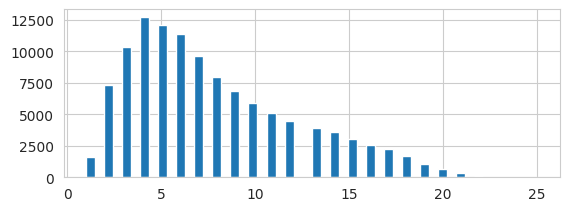

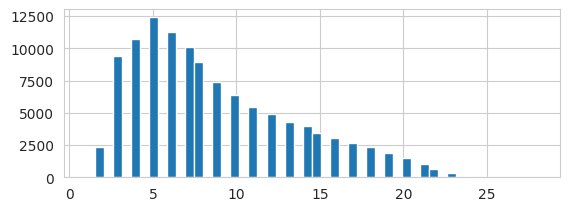

In [13]:
question_lengths = [len(s) for s in train_encoder_input]
print(f"maximum question sequence length >> {np.max(question_lengths)}")

answer_lengths = [len(s) for s in train_decoder_input]
print(f"maximum answer sequence length >> {np.max(answer_lengths)}")

plt.subplot(2,1,1)
plt.hist(question_lengths,bins=50)
plt.show()

plt.subplot(2,1,2)
plt.hist(answer_lengths,bins=50)
plt.show()

In [14]:
train_encoder_input = pad_sequences(train_encoder_input,padding='post')
train_decoder_input = pad_sequences(train_decoder_input,padding='post')
train_decoder_label = pad_sequences(train_decoder_label,padding='post')

print(train_encoder_input.shape)
print(train_decoder_input.shape)
print(train_decoder_label.shape)

question_sequence_size = train_encoder_input.shape[1]

answer_sequence_size = train_decoder_input.shape[1]

test_encoder_input = pad_sequences(test_encoder_input,padding='post',maxlen=question_sequence_size)
test_decoder_input = pad_sequences(test_decoder_input,padding='post',maxlen=answer_sequence_size)
test_decoder_label = pad_sequences(test_decoder_label,padding='post',maxlen=answer_sequence_size)

print(test_encoder_input.shape)
print(test_decoder_input.shape)
print(test_decoder_label.shape)

(114732, 25)
(114732, 28)
(114732, 28)
(12748, 25)
(12748, 28)
(12748, 28)


In [15]:
train_encoder_input

array([[   7,   25,    1, ...,    0,    0,    0],
       [  66,    1,   15, ...,    0,    0,    0],
       [1163,   28, 3113, ...,    0,    0,    0],
       ...,
       [  15,  119,    9, ...,    0,    0,    0],
       [ 330,  999,  100, ...,    0,    0,    0],
       [  76,   20,  172, ...,    0,    0,    0]], dtype=int32)

# Glove Emdding

# Read File

In [16]:
embedding_dict = dict()

f = open(os.path.join('/kaggle/input/glove6b50dtxt/glove.6B.50d.txt'),encoding='utf-8')

for line in f:
    tokens = line.split()
    word = tokens[0]
    vector = tokens[1:]
    vector =  np.asarray(vector,dtype='float32')
    embedding_dict[word] = vector
    
f.close()

In [17]:
#29930 ,50
embedding_size = len(embedding_dict['world'])
question_embedding_matrix =  np.zeros((question_vocab_size,embedding_size))
for word,idx in q_tok.word_index.items():
    #29929  
    if idx <= question_word_size:
        # get vector
        vector = embedding_dict.get(word)
        if vector is not None:
            question_embedding_matrix[idx] = np.asarray(vector,dtype='float32')

In [18]:

answer_embedding_matrix =  np.zeros((answer_vocab_size,embedding_size))
for word,idx in q_tok.word_index.items():
    if idx <= answer_word_size:
        vector = embedding_dict.get(word)
        if vector is not None:
            answer_embedding_matrix[idx] = np.asarray(vector,dtype='float32')

In [19]:
print(f"There are {len(embedding_dict)} embedding vectors in total")
print(f"The size of embedding vector here >> {embedding_size}")

There are 400000 embedding vectors in total
The size of embedding vector here >> 50


In [20]:
def seq2question(encoder_input):
    #  index_word=output: go
    ret=[q_tok.index_word[idx] for idx in encoder_input if idx != 0]
    return ' '.join(ret)

In [21]:
def seq2answer(decoder_input):
    ret = []
    for idx in decoder_input:
        if idx != 0:
            if a_tok.index_word[idx] != 'sos' and a_tok.index_word[idx] != 'eos':
                ret.append(a_tok.index_word[idx])
                
    return ' '.join(ret)

# Attention


In [22]:
import tensorflow
from tensorflow.keras.layers import Attention
 # Attention=Dot-product attention layer

# Model 

# Encoder 

In [23]:
hidden_size = 256

encoder_input = Input(shape=[question_sequence_size])
# 29930,50
encoder_embedding = Embedding(question_vocab_size,embedding_size,mask_zero=True,trainable=True,weights=[question_embedding_matrix])
encoder_embedded = encoder_embedding(encoder_input)
# None,24,50                                                                             #drop input   regularization method
lstm1 = Bidirectional(LSTM(hidden_size,return_sequences=True,return_state=True,dropout=0.3,recurrent_dropout=0.3))
encoder_output1,_,_,_,_ = lstm1(encoder_embedded)

lstm2 = Bidirectional(LSTM(hidden_size,return_sequences=True,return_state=True,dropout=0.3,recurrent_dropout=0.3))
encoder_output2,_,_,_,_ = lstm2(encoder_output1)

lstm3 = Bidirectional(LSTM(128,return_sequences=True,return_state=True,dropout=0.3,recurrent_dropout=0.3))
encoder_output3,encoder_forward_h3,encoder_forward_c3,encoder_backward_h3,encoder_backward_c3= lstm3(encoder_output2)


encoder_h3 = Concatenate()([encoder_forward_h3,encoder_backward_h3])
encoder_dense_h = Dense(hidden_size)
encoder_h3 = encoder_dense_h(encoder_h3)

encoder_c3 = Concatenate()([encoder_forward_c3,encoder_backward_c3])
encoder_dense_c = Dense(hidden_size)
encoder_c3 = encoder_dense_c(encoder_c3)

gen_encoder = Model(encoder_input,[encoder_h3,encoder_c3])

In [24]:
gen_encoder.summary()


Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 25)]         0           []                               
                                                                                                  
 embedding (Embedding)          (None, 25, 50)       1498750     ['input_1[0][0]']                
                                                                                                  
 bidirectional (Bidirectional)  [(None, 25, 512),    628736      ['embedding[0][0]']              
                                 (None, 256),                                                     
                                 (None, 256),                                                     
                                 (None, 256),                                                 

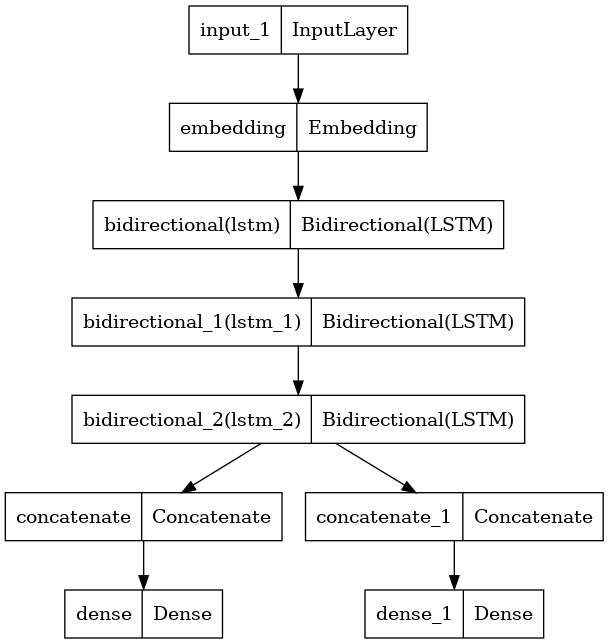

In [25]:
from keras.utils import plot_model
plot_model(gen_encoder)

# Decoder

In [26]:
#decoder part start
decoder_input = Input(shape=(None,))
decoder_embedding = Embedding(answer_vocab_size,embedding_size,mask_zero=True,trainable=True,weights=[answer_embedding_matrix])
decoder_embedded = decoder_embedding(decoder_input)

decoder_lstm = LSTM(hidden_size,return_sequences=True,return_state=True)
decoder_output,_,_ = decoder_lstm(decoder_embedded,initial_state=[encoder_h3,encoder_c3])
print(decoder_output)
print(encoder_output3)
#Attention layer (query,value)
attn_layer = Attention()
attention_context = attn_layer([decoder_output,encoder_output3])

decoder_output = Concatenate()([decoder_output,attention_context])

dense1 = Dense(512,activation='relu')
decoder_output = dense1(decoder_output)

decoder_softmax = Dense(answer_vocab_size,activation='softmax')
decoder_output = decoder_softmax(decoder_output)

KerasTensor(type_spec=TensorSpec(shape=(None, None, 256), dtype=tf.float32, name=None), name='lstm_3/PartitionedCall:1', description="created by layer 'lstm_3'")
KerasTensor(type_spec=TensorSpec(shape=(None, 25, 256), dtype=tf.float32, name=None), name='bidirectional_2/concat:0', description="created by layer 'bidirectional_2'")


In [27]:
trainer = Model([encoder_input,decoder_input],decoder_output)
loss = tensorflow.keras.losses.SparseCategoricalCrossentropy()
trainer.compile(loss=loss,optimizer='adam',metrics=['accuracy'])
trainer.summary()

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 25)]         0           []                               
                                                                                                  
 embedding (Embedding)          (None, 25, 50)       1498750     ['input_1[0][0]']                
                                                                                                  
 bidirectional (Bidirectional)  [(None, 25, 512),    628736      ['embedding[0][0]']              
                                 (None, 256),                                                     
                                 (None, 256),                                                     
                                 (None, 256),                                               

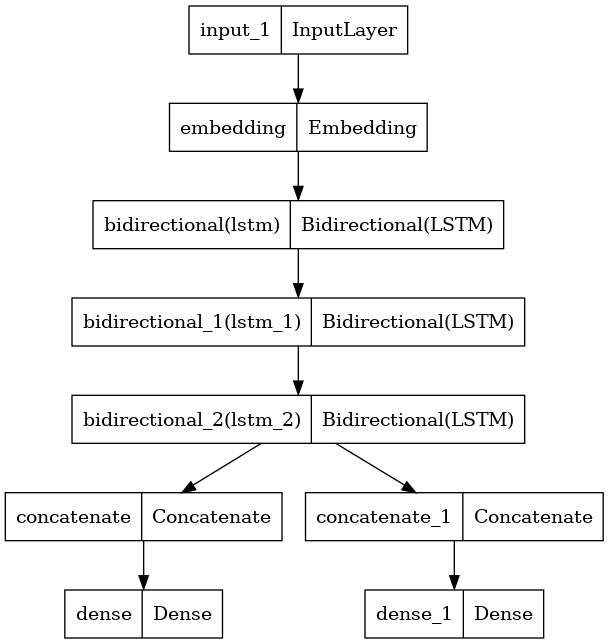

In [28]:
#generator model
gen_encoder = Model(encoder_input,[encoder_output3,encoder_h3,encoder_c3])
# 29915
gen_decoder_value_input = Input(shape=(question_sequence_size,hidden_size))
gen_decoder_h_input = Input(shape=[hidden_size])
gen_decoder_c_input = Input(shape=[hidden_size])

gen_decoder_embedded = decoder_embedding(decoder_input)
gen_decoder_output,gen_decoder_h,gen_decoder_c = decoder_lstm(gen_decoder_embedded,initial_state=[gen_decoder_h_input,gen_decoder_c_input])

#attention([querys,values])
gen_attention_context = attn_layer([gen_decoder_output,gen_decoder_value_input])
gen_decoder_output = Concatenate()([gen_decoder_output,gen_attention_context])

gen_decoder_output = dense1(gen_decoder_output)
gen_decoder_output = decoder_softmax(gen_decoder_output)

gen_decoder = Model([decoder_input]+[gen_decoder_value_input,gen_decoder_h_input,gen_decoder_c_input],[gen_decoder_output]+[gen_decoder_h,gen_decoder_c])
plot_model(gen_encoder)


In [29]:
train_hist = trainer.fit([train_encoder_input,train_decoder_input],train_decoder_label,epochs=20,validation_split=0.3,batch_size=512)

Epoch 1/20
157/157 [==============================] - 249s 1s/step - loss: 6.1075 - accuracy: 0.1299 - val_loss: 5.7456 - val_accuracy: 0.1380
Epoch 2/20
157/157 [==============================] - 202s 1s/step - loss: 5.4841 - accuracy: 0.1583 - val_loss: 5.3737 - val_accuracy: 0.1767
Epoch 3/20
157/157 [==============================] - 195s 1s/step - loss: 5.1820 - accuracy: 0.1879 - val_loss: 5.2031 - val_accuracy: 0.1991
Epoch 4/20
157/157 [==============================] - 192s 1s/step - loss: 4.9977 - accuracy: 0.2038 - val_loss: 5.1060 - val_accuracy: 0.2091
Epoch 5/20
157/157 [==============================] - 192s 1s/step - loss: 4.8662 - accuracy: 0.2120 - val_loss: 5.0489 - val_accuracy: 0.2147
Epoch 6/20
157/157 [==============================] - 187s 1s/step - loss: 4.7599 - accuracy: 0.2173 - val_loss: 5.0050 - val_accuracy: 0.2202
Epoch 7/20
157/157 [==============================] - 191s 1s/step - loss: 4.6638 - accuracy: 0.2219 - val_loss: 4.9974 - val_accuracy: 0.2229

In [30]:
def generate_from_input(encoder_input):
    #             [1,2,3]
    values,h,c = gen_encoder.predict(encoder_input)
    decoder_seq = np.zeros((1,1))
    # sos:1
    decoder_seq[0,0] = a_tok.word_index['sos']
    
    generated_sent = ''
    stop_condition= False
    
    while not stop_condition:
        output,h_state,c_state = gen_decoder.predict([decoder_seq]+[values,h,c])
        sampled_index = np.argmax(output[0,-1,:])
        # output :am , output :I 
        sampled_word = a_tok.index_word[sampled_index]
        
        if sampled_word != 'eos':
            generated_sent = generated_sent + sampled_word + ' '
        
        if sampled_word == 'eos' or len(generated_sent) >= answer_sequence_size:
            stop_condition=True
        
        decoder_seq = np.zeros((1,1))
        decoder_seq[0,0] = sampled_index
        h,c = h_state,c_state
        # Remove spaces at the beginning 
    return generated_sent.strip()


# Test 

In [31]:
#results on train dataset
sample_indices= [5,26,7,11,735,662,115,321]

for idx in sample_indices:
    generated_sent = generate_from_input(train_encoder_input[idx:idx+1])
    print(f"Question >> {seq2question(train_encoder_input[idx])}")
    print(f"Answer(Generated) >> {generated_sent}")
    print(f"Answer(Label) >> {seq2answer(train_decoder_input[idx])}")
    print("="*45)
    print("\n")

1/1 [==============================] - 0s 20ms/step
Question >> i don't know i just thought it was interesting
Answer(Generated) >> i am not sure
Answer(Label) >> you know what jerry who really cares at this point


1/1 [==============================] - 0s 21ms/step
Question >> oh no sir i was just assembling my notes
Answer(Generated) >> i am not sure
Answer(Label) >> you know dr maximus our commissioner for animal affairs


1/1 [==============================] - 0s 22ms/step
Question >> i've always wanted a watch like that
Answer(Generated) >> i am not sure
Answer(Label) >> it is yours


1/1 [==============================] - 0s 20ms/step
Question >> then what are you getting so upset about
Answer(Generated) >> i am not sure
Answer(Label) >> what did laura say do you know why she left


1/1 [==============================] - 0s 22ms/step
Question >> but david
Answer(Generated) >> i am not going to be a good
Answer(Label) >> i was not hallucinating


1/1 [============================

In [32]:
#results on test dataset
sample_indices= [100,20,44,33]

for idx in sample_indices:
    generated_sent = generate_from_input(test_encoder_input[idx:idx+1])
    print(f"Question >> {seq2question(test_encoder_input[idx])}")
    print(f"Answer(Generated) >> {generated_sent}")
    print(f"Answer(Label) >> {seq2answer(test_decoder_input[idx])}")
    print("="*45)
    print("\n")

1/1 [==============================] - 0s 20ms/step
Question >> we need signatures to the i can supply those oswald
Answer(Generated) >> i am not sure
Answer(Label) >> i could teach her my french flipper trick


1/1 [==============================] - 0s 21ms/step
Question >> give me the god damn gum
Answer(Generated) >> i am not sure
Answer(Label) >> just do not chew it


1/1 [==============================] - 0s 21ms/step
Question >> it's all over man we call your fucking bluff
Answer(Generated) >> i am not going to have a lot
Answer(Label) >> walter for christs sake he is crippled put him down


1/1 [==============================] - 0s 22ms/step
Question >> i can't take my eyes off you how can i drive when you drive me mad mad
Answer(Generated) >> i am not going to be a little
Answer(Label) >> rudolfo you dirty pig pull over


